# A/B Test Analysis: New vs. Old Landing Page

**Business question:** Does a redesigned landing page (`new_page`) convert more visitors than the current one (`old_page`)?

This notebook walks through the full analysis of a website A/B test: data quality checks, experiment design (hypotheses, sample size and power), a sample ratio check, the statistical test, and a launch recommendation.

**Data:** [Kaggle - A/B Testing (ab_data.csv)](https://www.kaggle.com/datasets/zhangluyuan/ab-testing). Download it and place it at `data/ab_data.csv` (see the README).

All conclusions printed in this notebook are generated from the data by code, so they always match the numbers shown.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest, proportion_confint, confint_proportions_2indep, proportion_effectsize
)
from statsmodels.stats.power import NormalIndPower

# ---- Experiment settings (change here, everything below updates) ----
DATA_PATH = "data/ab_data.csv"
ALPHA = 0.05          # significance level (two-sided)
POWER = 0.80          # desired statistical power
MDE_ABS = 0.01        # minimum detectable effect, in absolute conversion-rate points (1 pp)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load the data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Rows: 294,478  |  Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 2. Data quality checks

An A/B test is only as trustworthy as its assignment. Three things commonly go wrong:

1. **Missing values** in key columns.
2. **Mismatched assignment:** a user in `control` who saw `new_page`, or a user in `treatment` who saw `old_page`.
3. **Duplicate users:** the same `user_id` appearing more than once.

In [3]:
print("Missing values per column:")
print(df.isna().sum().to_string(), "\n")

print("Group vs. landing page (rows):")
print(pd.crosstab(df["group"], df["landing_page"]), "\n")

n_dup_ids = df["user_id"].duplicated().sum()
print(f"Rows with a repeated user_id: {n_dup_ids:,}")
print(f"Experiment period: {df['timestamp'].min():%Y-%m-%d} to {df['timestamp'].max():%Y-%m-%d}")

Missing values per column:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0 

Group vs. landing page (rows):
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965 

Rows with a repeated user_id: 3,894
Experiment period: 2017-01-02 to 2017-01-24


In [4]:
rows_before = len(df)

# Keep only rows where the shown page matches the assigned group
valid = ((df["group"] == "control") & (df["landing_page"] == "old_page")) | \
        ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
n_mismatch = (~valid).sum()
df = df[valid]

# Keep the first visit of each user, so each user counts once
n_dups_after = df["user_id"].duplicated().sum()
df = df.sort_values("timestamp").drop_duplicates("user_id", keep="first").reset_index(drop=True)

print(f"Rows before cleaning:            {rows_before:,}")
print(f"Removed - mismatched assignment: {n_mismatch:,}")
print(f"Removed - duplicate user_id:     {n_dups_after:,}")
print(f"Rows after cleaning:             {len(df):,}")
assert df["user_id"].is_unique

Rows before cleaning:            294,478
Removed - mismatched assignment: 3,893
Removed - duplicate user_id:     1
Rows after cleaning:             290,584


## 3. Experiment design

**Hypotheses** (two-sided test on the conversion rate, where *p* is the share of visitors who convert):

- H0: p_new = p_old (the new page makes no difference)
- H1: p_new ≠ p_old

**Parameters:** significance level α, desired power, and a **minimum detectable effect (MDE)**, the smallest change that would matter to the business. The MDE is a business choice, not something to take from the data. Here it is set in the settings cell above.

Below: how many users per group would we have needed to detect that MDE, and how does that compare to what we actually have?

In [5]:
control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]

p_base = control.mean()
effect = proportion_effectsize(p_base + MDE_ABS, p_base)   # Cohen's h
analysis = NormalIndPower()

n_required = analysis.solve_power(effect_size=effect, alpha=ALPHA, power=POWER,
                                  ratio=1.0, alternative="two-sided")
n_actual = min(len(control), len(treatment))

# Smallest absolute lift we could detect with the sample we actually have
h_detectable = analysis.solve_power(nobs1=n_actual, alpha=ALPHA, power=POWER,
                                    ratio=1.0, alternative="two-sided")
p_detectable = np.sin((h_detectable + 2 * np.arcsin(np.sqrt(p_base))) / 2) ** 2
mde_achieved = p_detectable - p_base

print(f"Baseline conversion rate (control): {p_base:.2%}")
print(f"Planned MDE: {MDE_ABS:.2%} points absolute")
print(f"Required sample size per group:    {n_required:,.0f}")
print(f"Actual sample size (smaller group): {n_actual:,}")
print(f"Smallest effect detectable with our sample (80% power): {mde_achieved:.3%} points")

Baseline conversion rate (control): 12.04%
Planned MDE: 1.00% points absolute
Required sample size per group:    17,209
Actual sample size (smaller group): 145,274
Smallest effect detectable with our sample (80% power): 0.340% points


## 4. Sample ratio mismatch (SRM) check

If users were randomly split 50/50, the group sizes should be very close. A significant imbalance suggests a problem in the assignment or logging process, and the results should not be trusted until it is explained.

In [6]:
counts = df["group"].value_counts().reindex(["control", "treatment"])
chi2_srm, p_srm = stats.chisquare(counts.values, f_exp=[counts.sum() / 2] * 2)
print(counts.to_string())
print(f"\nSRM chi-square = {chi2_srm:.3f}, p = {p_srm:.4f}")
print("OK: no evidence of sample ratio mismatch (p > 0.01)." if p_srm > 0.01
      else "WARNING: possible sample ratio mismatch - investigate before trusting results.")

group
control      145274
treatment    145310

SRM chi-square = 0.004, p = 0.9468
OK: no evidence of sample ratio mismatch (p > 0.01).


## 5. Exploratory analysis

In [7]:
summary = (df.groupby("group")["converted"]
             .agg(users="count", conversions="sum", conversion_rate="mean"))
ci = [proportion_confint(c, n, alpha=ALPHA, method="wilson")
      for c, n in zip(summary["conversions"], summary["users"])]
summary["ci_low"] = [c[0] for c in ci]
summary["ci_high"] = [c[1] for c in ci]
summary

,users,conversions,conversion_rate,ci_low,ci_high
group,,,,,
control,145274,17489,0.1204,0.1187,0.1221
treatment,145310,17264,0.1188,0.1172,0.1205


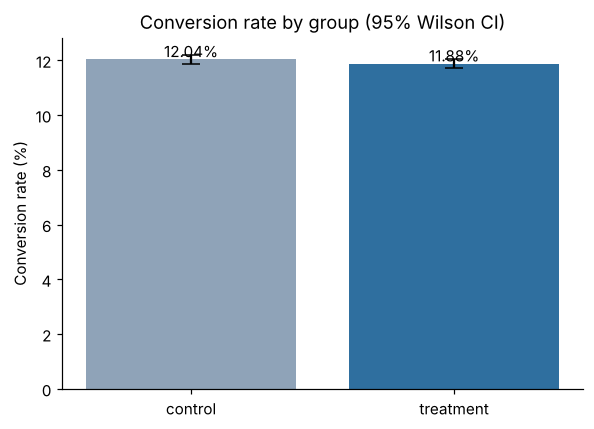

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4))
order = ["control", "treatment"]
rates = summary.loc[order, "conversion_rate"] * 100
err_low = (summary.loc[order, "conversion_rate"] - summary.loc[order, "ci_low"]) * 100
err_high = (summary.loc[order, "ci_high"] - summary.loc[order, "conversion_rate"]) * 100
ax.bar(order, rates, yerr=[err_low, err_high], capsize=6, color=["#8fa3b8", "#2f6f9f"])
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion rate by group (95% Wilson CI)")
for i, r in enumerate(rates):
    ax.text(i, r + 0.08, f"{r:.2f}%", ha="center")
plt.tight_layout()
plt.show()

**Stability over time.** A quick check that the difference is not driven by a few unusual days (for example a novelty effect that fades).

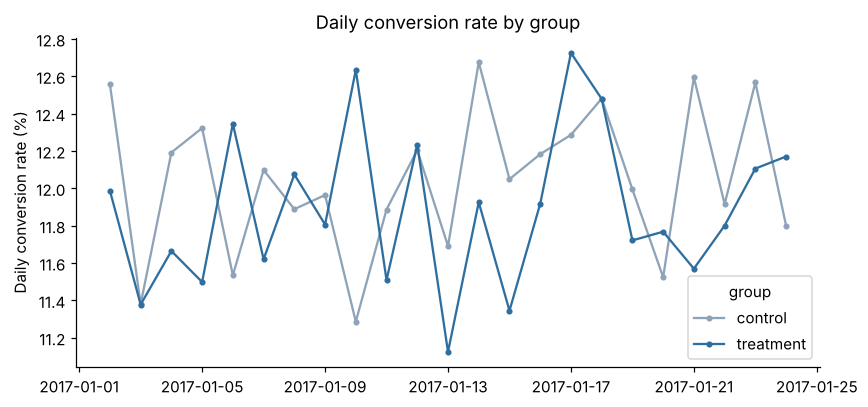

In [9]:
daily = (df.assign(date=df["timestamp"].dt.date)
           .groupby(["date", "group"])["converted"].mean().unstack() * 100)
ax = daily.plot(figsize=(8, 3.8), marker="o", ms=3, color=["#8fa3b8", "#2f6f9f"])
ax.set_ylabel("Daily conversion rate (%)")
ax.set_xlabel("")
ax.set_title("Daily conversion rate by group")
plt.tight_layout()
plt.show()

## 6. Hypothesis test

A **two-proportion z-test** compares the two conversion rates. With samples this large the normal approximation is appropriate. A chi-square test of independence is run as a cross-check (it is equivalent for a 2x2 table). Alongside the p-value, the **confidence interval for the difference** shows how large the effect could plausibly be, which matters more for a business decision than the p-value alone.

In [10]:
# Plain Python ints avoid integer overflow inside statsmodels' score-interval formulas
x = np.array([int(treatment.sum()), int(control.sum())], dtype=object)
n = np.array([int(len(treatment)), int(len(control))], dtype=object)

z_stat, p_value = proportions_ztest(x.astype(float), n.astype(float), alternative="two-sided")

# Confidence intervals for the absolute difference and the relative lift
diff_low, diff_high = confint_proportions_2indep(x[0], n[0], x[1], n[1],
                                                 compare="diff", method="newcomb", alpha=ALPHA)
rr_low, rr_high = confint_proportions_2indep(x[0], n[0], x[1], n[1],
                                             compare="ratio", method="score", alpha=ALPHA)

p_new, p_old = float(x[0]) / n[0], float(x[1]) / n[1]
diff = p_new - p_old

# Cross-check with chi-square test of independence (no continuity correction)
table = np.array([[x[0], n[0] - x[0]], [x[1], n[1] - x[1]]], dtype=float)
chi2, p_chi2, _, _ = stats.chi2_contingency(table, correction=False)

results = pd.Series({
    "Conversion - old page": p_old,
    "Conversion - new page": p_new,
    "Absolute difference (new - old)": diff,
    f"{1-ALPHA:.0%} CI for difference (low)": diff_low,
    f"{1-ALPHA:.0%} CI for difference (high)": diff_high,
    "Relative lift": diff / p_old,
    f"{1-ALPHA:.0%} CI for rate ratio (low)": rr_low,
    f"{1-ALPHA:.0%} CI for rate ratio (high)": rr_high,
    "z statistic": z_stat,
    "p-value (z-test)": p_value,
    "p-value (chi-square check)": p_chi2,
})
results.to_frame("value")

,value
Conversion - old page,0.1204
Conversion - new page,0.1188
Absolute difference (new - old),-0.0016
95% CI for difference (low),-0.0039
95% CI for difference (high),0.0008
Relative lift,-0.0131
95% CI for rate ratio (low),0.9676
95% CI for rate ratio (high),1.0066
z statistic,-1.3109
p-value (z-test),0.1899


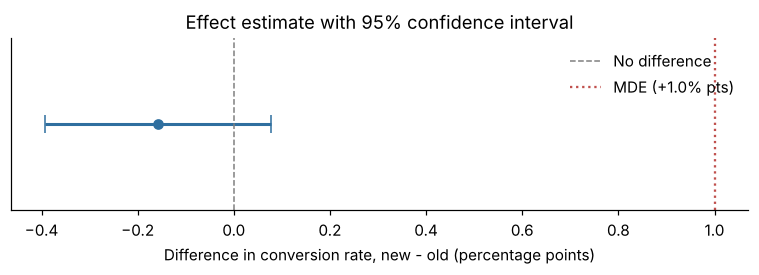

In [11]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.errorbar(diff * 100, 0, xerr=[[ (diff - diff_low) * 100 ], [ (diff_high - diff) * 100 ]],
            fmt="o", color="#2f6f9f", capsize=6, lw=2)
ax.axvline(0, color="grey", ls="--", lw=1, label="No difference")
ax.axvline(MDE_ABS * 100, color="#c0504d", ls=":", lw=1.5, label=f"MDE (+{MDE_ABS:.1%} pts)")
ax.set_yticks([])
ax.set_xlabel("Difference in conversion rate, new - old (percentage points)")
ax.set_title(f"Effect estimate with {1-ALPHA:.0%} confidence interval")
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

## 7. Decision

The recommendation is derived from both **statistical significance** (is the difference real?) and **practical significance** (is it large enough to matter, compared with the MDE?).

In [12]:
significant = p_value < ALPHA

if significant and diff > 0:
    if diff_low >= MDE_ABS:
        verdict = "LAUNCH: the new page is significantly better and the lift clears the minimum detectable effect."
    else:
        verdict = ("LAUNCH WITH CAUTION: the new page is significantly better, "
                   "but the lower end of the interval is below the effect size the business cares about.")
elif significant and diff < 0:
    verdict = "DO NOT LAUNCH: the new page converts significantly worse than the old page."
else:
    if diff_high < MDE_ABS:
        verdict = ("DO NOT LAUNCH FOR CONVERSION: no significant difference, and the interval rules out "
                   "an improvement as large as the MDE. Keep the old page or decide on other grounds (cost, brand).")
    else:
        verdict = ("INCONCLUSIVE: no significant difference, but the interval still allows an effect "
                   "as large as the MDE. More data would be needed to decide.")

print(f"Result: new page {p_new:.2%} vs. old page {p_old:.2%} "
      f"(difference {diff*100:+.2f} pts, {1-ALPHA:.0%} CI [{diff_low*100:+.2f}, {diff_high*100:+.2f}] pts, p = {p_value:.4f}).")
print(f"Sample: {n[0]:,} / {n[1]:,} users per group; required for the planned MDE: {n_required:,.0f}.")
print()
print(verdict)

Result: new page 11.88% vs. old page 12.04% (difference -0.16 pts, 95% CI [-0.39, +0.08] pts, p = 0.1899).
Sample: 145,310 / 145,274 users per group; required for the planned MDE: 17,209.

DO NOT LAUNCH FOR CONVERSION: no significant difference, and the interval rules out an improvement as large as the MDE. Keep the old page or decide on other grounds (cost, brand).


## 8. Limitations and next steps

- **One metric.** Only conversion was measured. A real launch decision would also check secondary metrics (revenue per visitor, bounce rate) and guardrail metrics (page load time, complaints).
- **Short, fixed window.** The test runs for a limited period, so weekly cycles or novelty effects could still influence the result. The daily chart above is a first check, not proof.
- **No user attributes.** The dataset has no country, device or traffic source, so effects could not be compared across segments. With that data, a segment analysis (and a correction for multiple comparisons) would be the next step.
- **Fixed-horizon test.** The test assumes the sample size was fixed in advance. Stopping early after looking at results would inflate the false-positive rate.